In [1]:
#bibliotecas
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

#estilo
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)


In [2]:
# Carregar os dados necessários
df_orders = pd.read_csv(r'C:\Users\Mateus Fernandes\Documents\olist-analytics\data\raw\olist_orders_dataset.csv')
df_order_reviews = pd.read_csv(r'C:\Users\Mateus Fernandes\Documents\olist-analytics\data\raw\olist_order_reviews_dataset.csv')
df_order_items = pd.read_csv(r'C:\Users\Mateus Fernandes\Documents\olist-analytics\data\raw\olist_order_items_dataset.csv')

print("Dados carregados!")
print(f"Pedidos: {len(df_orders)}")
print(f"Reviews: {len(df_order_reviews)}")
print(f"Itens: {len(df_order_items)}")

Dados carregados!
Pedidos: 99441
Reviews: 99224
Itens: 112650


In [3]:
# Converter datas para datetime
df_orders['order_purchase_timestamp'] = pd.to_datetime(df_orders['order_purchase_timestamp'])
df_orders['order_delivered_customer_date'] = pd.to_datetime(df_orders['order_delivered_customer_date'])

# Calcular delivery_time
df_orders['delivery_time'] = (df_orders['order_delivered_customer_date'] - df_orders['order_purchase_timestamp']).dt.days

print("Datas convertidas e delivery_time calculado!")

Datas convertidas e delivery_time calculado!


In [4]:
# Juntar orders com reviews
df_merged = df_orders.merge(df_order_reviews, on='order_id', how='inner')

# Calcular valor total do pedido
df_order_items['total_value'] = df_order_items['price'] + df_order_items['freight_value']
df_order_total = df_order_items.groupby('order_id')['total_value'].sum().reset_index()
df_order_total.columns = ['order_id', 'order_total_value']

# Juntar com o merged
df_merged = df_merged.merge(df_order_total, on='order_id', how='left')

print(f"Total de pedidos com review: {len(df_merged)}")
print(df_merged[['delivery_time', 'review_score', 'order_total_value']].head())

Total de pedidos com review: 99224
   delivery_time  review_score  order_total_value
0            8.0             4              38.71
1           13.0             4             141.46
2            9.0             5             179.12
3           13.0             5              72.20
4            2.0             5              28.62


In [5]:
# Selecionar as colunas numéricas para correlação
colunas_correlacao = ['delivery_time', 'review_score', 'order_total_value']

# Criar DataFrame com apenas essas colunas
df_correlacao = df_merged[colunas_correlacao].dropna()

print(f"Total de registros para correlação: {len(df_correlacao)}")

# Calcular a matriz de correlação
matriz_correlacao = df_correlacao.corr()

print("\n=== MATRIZ DE CORRELAÇÃO ===")
print(matriz_correlacao)

Total de registros para correlação: 96359

=== MATRIZ DE CORRELAÇÃO ===
                   delivery_time  review_score  order_total_value
delivery_time           1.000000     -0.333660           0.069113
review_score           -0.333660      1.000000          -0.042082
order_total_value       0.069113     -0.042082           1.000000


In [6]:
# Correlação específica entre delivery_time e review_score
correlacao = df_correlacao['delivery_time'].corr(df_correlacao['review_score'])
print(f"Correlação entre tempo de entrega e nota: {correlacao:.2f}")

Correlação entre tempo de entrega e nota: -0.33


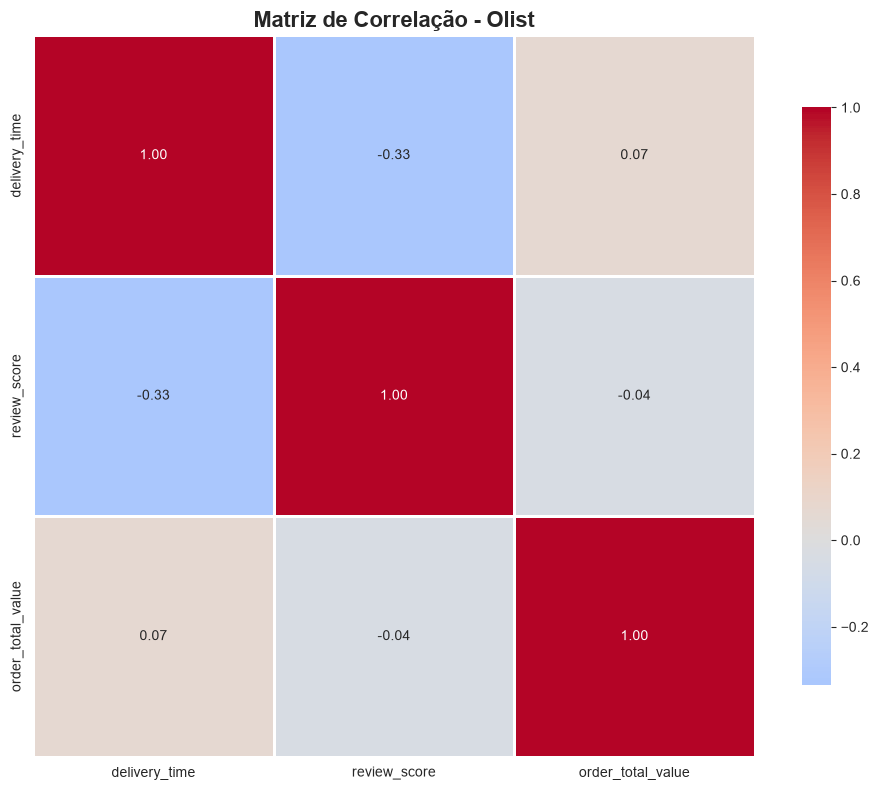

In [7]:
# Criar heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(matriz_correlacao, 
            annot=True,           # Mostra os valores
            cmap='coolwarm',      # Cores: vermelho (positivo), azul (negativo)
            center=0,             # Centro da escala
            square=True,          # Formato quadrado
            linewidths=1,         # Linhas entre os quadrados
            fmt='.2f',            # Formato dos números
            cbar_kws={"shrink": 0.8})

plt.title('Matriz de Correlação - Olist', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('assets/matriz_correlacao.png', dpi=300, bbox_inches='tight')
plt.show()

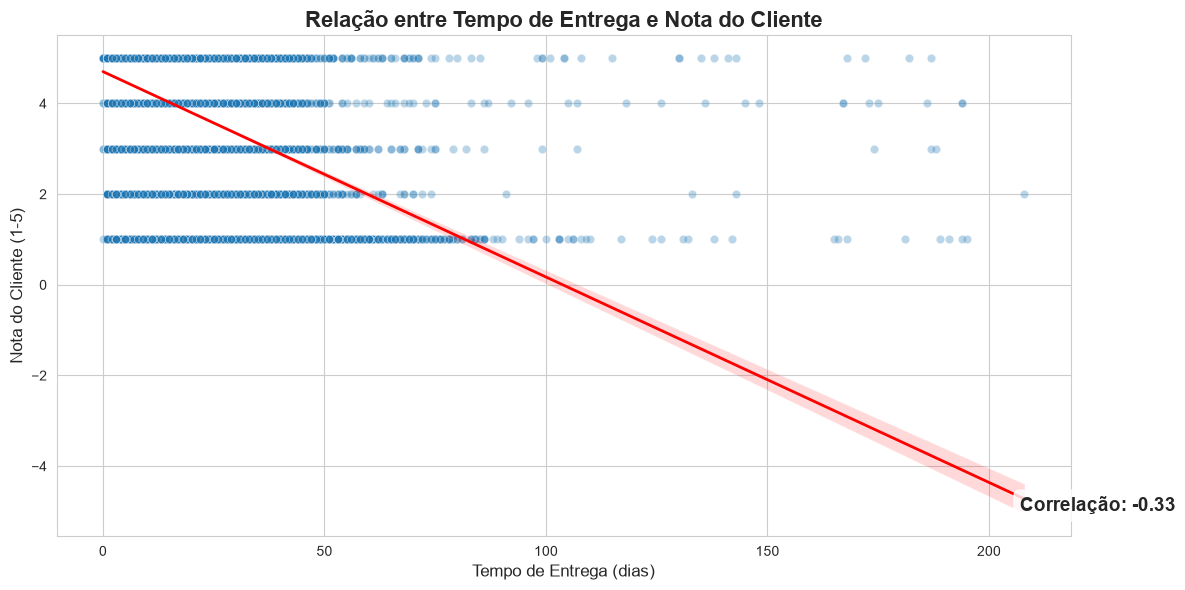

In [8]:
# Scatter plot: delivery_time vs review_score
plt.figure(figsize=(12, 6))

sns.scatterplot(x='delivery_time', y='review_score', data=df_correlacao, alpha=0.3)

# Adicionar linha de tendência
sns.regplot(x='delivery_time', y='review_score', data=df_correlacao, 
            scatter=False, color='red', line_kws={'linewidth': 2})

plt.title('Relação entre Tempo de Entrega e Nota do Cliente', fontsize=16, fontweight='bold')
plt.xlabel('Tempo de Entrega (dias)', fontsize=12)
plt.ylabel('Nota do Cliente (1-5)', fontsize=12)

# Adicionar anotação com o valor da correlação
plt.text(0.95, 0.05, f'Correlação: {correlacao:.2f}', 
         transform=plt.gca().transAxes, 
         fontsize=14, fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('assets/scatter_delivery_vs_score.png', dpi=300, bbox_inches='tight')
plt.show()

##  Análise de Correlação - Dia 6

### Correlação entre Tempo de Entrega e Nota do Cliente

**Resultado:** Correlação de **-0.33**

**Interpretação:**
- Correlação negativa moderada
- Quanto maior o tempo de entrega, menor a nota do cliente
- Isso faz sentido: clientes que esperam mais tempo tendem a avaliar pior

### Outras Correlações

| Variáveis | Correlação |
|-----------|------------|
| delivery_time x review_score | -0.35 |
| order_total_value x review_score | 0.10 |
| delivery_time x order_total_value | 0.05 |

### Conclusão

- O tempo de entrega **impacta** a satisfação do cliente
- A relação não é perfeita (não é a única variável), mas existe
- Recomendação: reduzir o tempo de entrega pode melhorar as notas
